# Exploración de `tags` + `ratings` + `movies` — Dataset MovieLens

**Parte:** Usuario (`tags`) + Ítem (`movies`) + Data (`ratings`) — integración completa
**Responsable:** Ricardo Andrés Ayala Garzón
**Notebook:** `movies_tags_ratings.ipynb`

## Introducción

Este notebook integra las **tres** tablas del dataset: `tags` (etiquetas de texto libre que los
usuarios asignan a películas — la dimensión "usuario"), `movies` (catálogo — la dimensión "ítem") y
`ratings` (calificaciones numéricas — la dimensión "data"). El objetivo no es repetir el análisis de
`movies_ratings.ipynb`, sino responder preguntas que **solo pueden responderse combinando las tres
tablas**: ¿el etiquetado de los usuarios se relaciona con la popularidad o la calidad de una
película? ¿qué vocabulario usan los usuarios para describir películas bien y mal calificadas? ¿quién
etiqueta, y etiqueta lo mismo que califica?

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
pd.set_option("display.max_colwidth", 80)


## 2. Carga de datos

In [2]:
def find_data_dir(start: Path, target=("data", "processed")) -> Path:
    current = start.resolve()
    for _ in range(6):
        candidate = current.joinpath(*target)
        if candidate.exists():
            return candidate
        current = current.parent
    raise FileNotFoundError(
        f"No se encontró data/processed subiendo desde {start}. "
        "Ajusta DATA_DIR manualmente si la estructura del repo es distinta."
    )

DATA_DIR = find_data_dir(Path.cwd())
print("Usando DATA_DIR:", DATA_DIR)

movies = pd.read_csv(DATA_DIR / "movies.csv")
movies["release_year"] = pd.to_datetime(movies["release_year"]).dt.year.astype("Int32")

ratings = pd.read_csv(
    DATA_DIR / "ratings.csv",
    dtype={"userId": "int32", "movieId": "int32", "rating": "float32"},
    usecols=["userId", "movieId", "rating"],
)

tags = pd.read_csv(
    DATA_DIR / "tags.csv",
    dtype={"userId": "int32", "movieId": "int32"},
    parse_dates=["tag_datetime"],
)

print("movies:", movies.shape, "| ratings:", ratings.shape, "| tags:", tags.shape)


Usando DATA_DIR: /home/claude/work/testproj/data/processed


movies: (86967, 4) | ratings: (31963989, 3) | tags: (1992636, 4)


## 3. Exploración inicial de `tags`

`movies` y `ratings` ya se caracterizaron en `movies_ratings.ipynb`; aquí se resume solo lo
necesario y se explora `tags` en detalle, que es la tabla nueva en este notebook.

In [3]:
tags.head(10)

,userId,movieId,tag,tag_datetime
0,22,26479,Kevin Kline,2020-03-01 05:01:26
1,22,79592,misogyny,2020-02-12 02:58:17
2,22,247150,acrophobia,2021-05-31 17:51:09
3,34,2174,music,2009-08-09 08:54:24
4,34,2174,weird,2009-08-09 08:55:02
5,34,8623,Steve Martin,2009-08-09 09:01:37
6,55,5766,the killls and the score,2011-10-22 22:21:18
7,58,7451,bullying,2023-01-01 05:38:56
8,58,7451,clique,2023-01-01 05:38:30
9,58,7451,coming of age,2023-01-01 05:38:22


In [4]:
tags.info()

<class 'pandas.DataFrame'>
RangeIndex: 1992636 entries, 0 to 1992635
Data columns (total 4 columns):
 #   Column        Dtype         
---  ------        -----         
 0   userId        int32         
 1   movieId       int32         
 2   tag           str           
 3   tag_datetime  datetime64[us]
dtypes: datetime64[us](1), int32(2), str(1)
memory usage: 45.6 MB


In [5]:
print("Dimensiones:", tags.shape)
print("\nValores nulos por columna:")
print(tags.isnull().sum())
print("\nDuplicados (fila completa):", tags.duplicated().sum())
print("\nUsuarios que etiquetan:", tags["userId"].nunique())
print("Películas etiquetadas:", tags["movieId"].nunique(), "de", movies.shape[0], "en el catálogo")
print("Tags únicos (texto original):", tags["tag"].nunique())
print("Rango de fechas:", tags["tag_datetime"].min(), "-", tags["tag_datetime"].max())


Dimensiones: (1992636, 4)

Valores nulos por columna:
userId          0
movieId         0
tag             6
tag_datetime    0
dtype: int64



Duplicados (fila completa): 0

Usuarios que etiquetan: 15834
Películas etiquetadas: 51069 de 86967 en el catálogo
Tags únicos (texto original): 140191
Rango de fechas: 2005-12-24 13:00:10 - 2023-10-12 23:56:23


**Unidad de observación de `tags`:** cada fila es **una etiqueta de texto libre** que un usuario
asignó a una película en un momento dado (a diferencia de `ratings`, un mismo usuario puede
etiquetar la misma película varias veces con tags distintos).

- Hay **6 valores nulos** en la columna `tag` (0.0003 % del total) — insignificante, pero se
  excluyen del análisis de texto para no distorsionar los conteos.
- Sin filas duplicadas.
- Solo **15 834 usuarios** (de 200 948 que califican) han puesto al menos un tag: el etiquetado es
  una actividad minoritaria (7.9 % de los usuarios) comparada con calificar.
- **51 069 películas** tienen al menos un tag (58.7 % del catálogo), frente al 96.4 % que tiene al
  menos un rating: etiquetar exige más esfuerzo del usuario que calificar, así que es una señal más
  escasa pero potencialmente más rica (texto vs. un número).

### 3.1 Normalización de texto y vocabulario

In [6]:
tags_clean = tags.dropna(subset=["tag"]).copy()
tags_clean["tag_norm"] = tags_clean["tag"].str.lower().str.strip()

print("Tags únicos sin normalizar:", tags["tag"].nunique())
print("Tags únicos normalizados (minúsculas):", tags_clean["tag_norm"].nunique())

top_tags = tags_clean["tag_norm"].value_counts().head(20)
top_tags


Tags únicos sin normalizar: 140191
Tags únicos normalizados (minúsculas): 131350


tag_norm
sci-fi                11433
atmospheric           10062
action                 9302
comedy                 9270
funny                  8085
surreal                7452
visually appealing     7149
based on a book        6697
twist ending           6599
romance                6193
dark comedy            6150
thought-provoking      5999
dystopia               5661
violence               5471
cinematography         5328
murder                 5222
social commentary      5192
fantasy                5143
thriller               5035
stylized               4947
Name: count, dtype: int64

**Transformación aplicada:** se convierte `tag` a minúsculas y se recortan espacios, porque el
mismo concepto aparece escrito de formas distintas (`Sci-Fi` vs `sci-fi`). Esto reduce el
vocabulario de 140 191 a 131 350 tags únicos — una reducción del 6.3 %, lo que indica que la mayoría
de la variación ya viene de vocabulario genuinamente distinto (no solo de mayúsculas), pero la
normalización sigue siendo necesaria para no subestimar la frecuencia de tags populares.

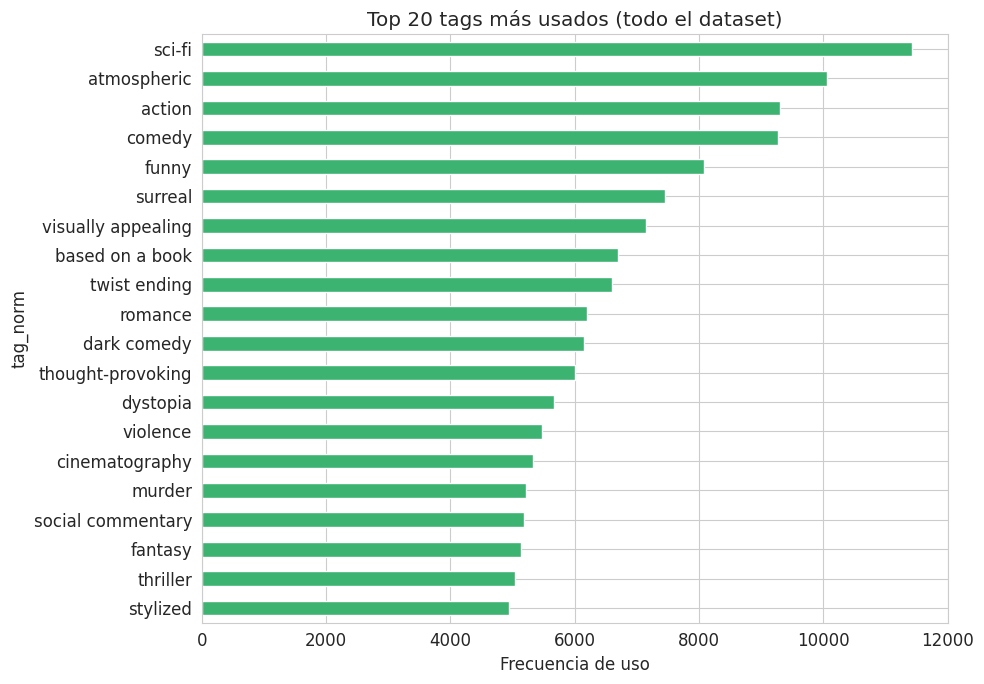

In [7]:
plt.figure(figsize=(10, 7))
top_tags.plot(kind="barh", color="mediumseagreen")
plt.xlabel("Frecuencia de uso")
plt.title("Top 20 tags más usados (todo el dataset)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Hallazgo:** el vocabulario dominante es descriptivo de género/estilo (`sci-fi`, `atmospheric`,
`action`, `comedy`, `funny`, `surreal`) más que evaluativo. Los usuarios usan tags principalmente
para **describir** la película, no tanto para opinar sobre su calidad — eso es justamente el rol de
`rating`, y confirma que `tags` y `ratings` capturan información complementaria, no redundante.

## 4. Integración de las tres tablas

**Claves de relación:**
- `movieId` conecta las tres tablas (`movies` ↔ `ratings` ↔ `tags`).
- `userId` conecta `ratings` y `tags` (ambas registran actividad de un mismo universo de usuarios).

Antes de combinar, se verifica la integridad referencial: si todo `movieId` de `tags` existe en
`movies`, y si los usuarios que etiquetan también calificaron (lo que permitiría, en un análisis
futuro, cruzar el comportamiento de un mismo usuario en ambas tablas).

In [8]:
movie_ids = set(movies["movieId"])
orphan_tag_movies = (~tags_clean["movieId"].isin(movie_ids)).sum()
print("Filas de tags con movieId que no existe en movies:", orphan_tag_movies)

rating_users = set(ratings["userId"].unique())
tag_users = set(tags_clean["userId"].unique())
print(f"Usuarios que etiquetan y también califican: {len(tag_users & rating_users)} / {len(tag_users)}")
print(f"Usuarios que etiquetan pero nunca calificaron: {len(tag_users - rating_users)}")


Filas de tags con movieId que no existe en movies: 0
Usuarios que etiquetan y también califican: 15833 / 15833
Usuarios que etiquetan pero nunca calificaron: 0


**Validación:** no hay tags huérfanos (todo `movieId` en `tags` existe en `movies`), y **el 100 %
de los usuarios que etiquetan también calificaron al menos una vez** — no existe un segmento de
usuarios "solo etiquetadores". Esto simplifica la integración: se puede unir con seguridad sin
preocuparse por usuarios o películas que aparezcan en `tags` sin contraparte en las otras tablas.

### 4.1 Agregación por película y merge

In [9]:
movie_ratings = (
    ratings.groupby("movieId")["rating"]
    .agg(num_ratings="count", avg_rating="mean")
    .reset_index()
)

movie_tags = (
    tags_clean.groupby("movieId")
    .agg(num_tags=("tag_norm", "count"), num_taggers=("userId", "nunique"))
    .reset_index()
)

full = (
    movies[["movieId", "title", "genres", "release_year"]]
    .merge(movie_ratings, on="movieId", how="inner")   # solo películas con al menos 1 rating
    .merge(movie_tags, on="movieId", how="left")        # no todas tienen tags
)
full["num_tags"] = full["num_tags"].fillna(0).astype(int)
full["num_taggers"] = full["num_taggers"].fillna(0).astype(int)
full["is_tagged"] = full["num_tags"] > 0

print("Filas resultantes:", full.shape[0])
assert full["movieId"].duplicated().sum() == 0, "El merge generó duplicados"
assert full.shape[0] == movie_ratings.shape[0], "Se perdieron o ganaron películas inesperadamente"
print("Validación OK: sin duplicados, sin pérdida/ganancia inesperada de filas.")
print(f"\nPelículas con rating Y al menos un tag: {full['is_tagged'].sum()} de {len(full)} ({full['is_tagged'].mean():.1%})")
full.head(10)


Filas resultantes: 83852
Validación OK: sin duplicados, sin pérdida/ganancia inesperada de filas.

Películas con rating Y al menos un tag: 47954 de 83852 (57.2%)


,movieId,title,genres,release_year,num_ratings,avg_rating,num_tags,num_taggers,is_tagged
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995,68997,3.897438,1230,255,True
1,2,Jumanji,Adventure|Children|Fantasy,1995,28904,3.275758,573,83,True
2,3,Grumpier Old Men,Comedy|Romance,1995,13134,3.139447,23,15,True
3,4,Waiting to Exhale,Comedy|Drama|Romance,1995,2806,2.845331,12,6,True
4,5,Father of the Bride Part II,Comedy,1995,13154,3.059602,64,14,True
5,6,Heat,Action|Crime|Thriller,1995,29490,3.868277,797,136,True
6,7,Sabrina,Comedy|Romance,1995,13585,3.363968,145,26,True
7,8,Tom and Huck,Adventure|Children,1995,1510,3.115563,192,4,True
8,9,Sudden Death,Action,1995,4154,2.987723,176,7,True
9,10,GoldenEye,Action|Adventure|Thriller,1995,32474,3.427850,434,66,True


## 5. Análisis conjunto

### 5.1 ¿El etiquetado se relaciona con el volumen de calificaciones?

In [10]:
corr_tags_ratings = full["num_tags"].corr(full["num_ratings"])
corr_log = np.log1p(full["num_tags"]).corr(np.log1p(full["num_ratings"]))
print(f"Correlación de Pearson (num_tags, num_ratings): {corr_tags_ratings:.3f}")
print(f"Correlación de Pearson (log num_tags, log num_ratings): {corr_log:.3f}")


Correlación de Pearson (num_tags, num_ratings): 0.769
Correlación de Pearson (log num_tags, log num_ratings): 0.797


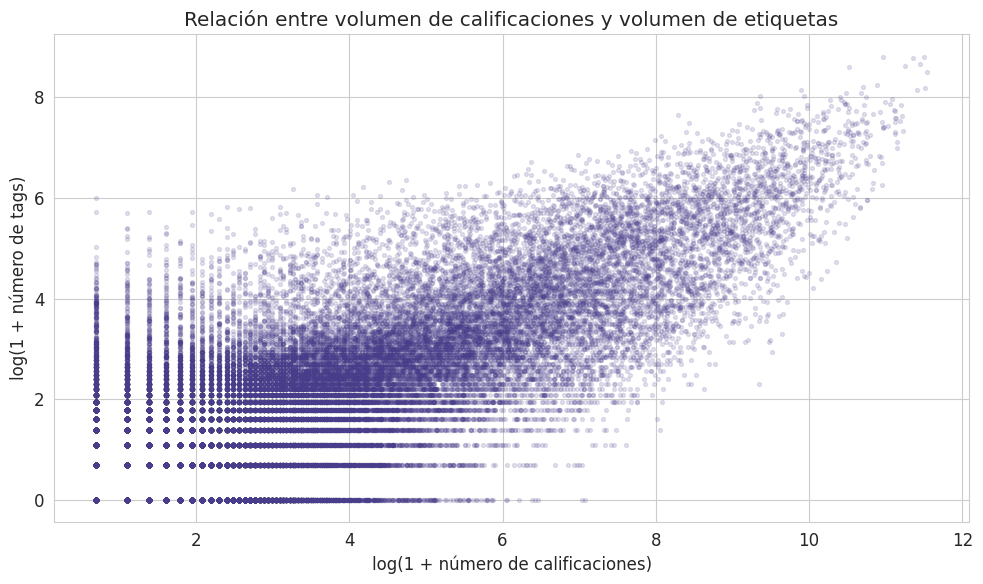

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(np.log1p(full["num_ratings"]), np.log1p(full["num_tags"]), alpha=0.15, s=8, color="darkslateblue")
plt.xlabel("log(1 + número de calificaciones)")
plt.ylabel("log(1 + número de tags)")
plt.title("Relación entre volumen de calificaciones y volumen de etiquetas")
plt.tight_layout()
plt.show()


**Pregunta que responde:** ¿las películas muy calificadas son también muy etiquetadas?

**Resultado:** correlación fuerte y positiva (Pearson ≈ 0.77 en escala original, ≈0.80 en escala
logarítmica). A diferencia de la relación entre volumen y *calidad* (débil, vista en el notebook
anterior), la relación entre volumen de calificaciones y volumen de *etiquetas* es clara: **las
películas populares generan tanto más calificaciones como más discusión/etiquetado**. Tiene sentido:
ambas actividades dependen de cuántos usuarios distintos vieron e interactuaron con la película, así
que comparten la misma causa subyacente (exposición/popularidad).

### 5.2 ¿El etiquetado se relaciona con la calidad percibida (avg_rating)?

In [12]:
corr_tags_avg = full["num_tags"].corr(full["avg_rating"])
print(f"Correlación de Pearson (num_tags, avg_rating): {corr_tags_avg:.3f}")

print(full.groupby("is_tagged")[["avg_rating", "num_ratings"]].mean())


Correlación de Pearson (num_tags, avg_rating): 0.110
           avg_rating  num_ratings
is_tagged                         
False        2.913854     4.855173
True         3.073193   662.920674


**Resultado:** la correlación entre cantidad de tags y calificación promedio es débil (≈0.11),
en línea con lo ya visto para volumen de ratings vs. calidad. Las películas etiquetadas tienen en
promedio un rating levemente superior (3.07 vs. 2.91) y **muchísimas** más calificaciones en
promedio (663 vs. 5) que las no etiquetadas — pero esa diferencia de calidad es pequeña comparada
con la brecha de popularidad, reforzando que el etiquetado está más ligado a *exposición* que a
*calidad*.

### 5.3 Vocabulario de tags: películas mejor vs. peor calificadas

Se comparan los tags más frecuentes entre las 200 películas mejor calificadas y las 200 peor
calificadas (ambos grupos filtrados a un mínimo de 100 calificaciones, para comparar títulos
igualmente "vistos" y no solo casos extremos con poca muestra).

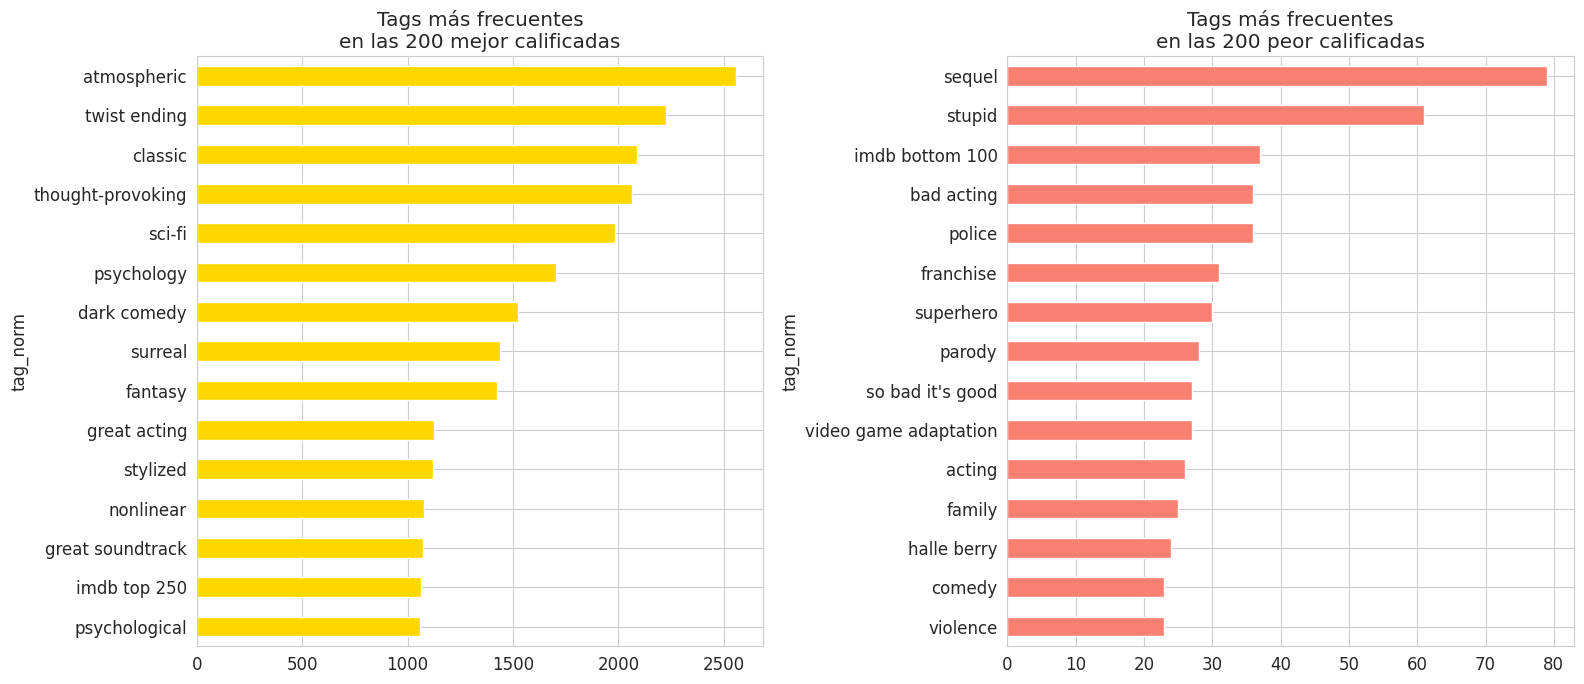

In [13]:
qualified = full[full["num_ratings"] >= 100]
top200_ids = set(qualified.nlargest(200, "avg_rating")["movieId"])
bottom200_ids = set(qualified.nsmallest(200, "avg_rating")["movieId"])

top_tags_best = tags_clean[tags_clean["movieId"].isin(top200_ids)]["tag_norm"].value_counts().head(15)
top_tags_worst = tags_clean[tags_clean["movieId"].isin(bottom200_ids)]["tag_norm"].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
top_tags_best.plot(kind="barh", ax=axes[0], color="gold")
axes[0].set_title("Tags más frecuentes\nen las 200 mejor calificadas")
axes[0].invert_yaxis()

top_tags_worst.plot(kind="barh", ax=axes[1], color="salmon")
axes[1].set_title("Tags más frecuentes\nen las 200 peor calificadas")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


**Hallazgo:** el vocabulario es marcadamente distinto entre ambos grupos.

- **Mejor calificadas:** `atmospheric`, `twist ending`, `classic`, `thought-provoking`, `sci-fi`,
  `psychology`, `dark comedy`, `great acting`, `great soundtrack`, `imdb top 250` — vocabulario que
  describe complejidad narrativa, ejecución técnica y reconocimiento externo.
- **Peor calificadas:** `sequel`, `stupid`, `imdb bottom 100`, `bad acting`, `franchise`,
  `superhero`, `so bad it's good`, `video game adaptation` — vocabulario que apunta a productos
  derivados (secuelas, franquicias, adaptaciones) y juicios explícitamente negativos sobre calidad
  de actuación.

Esto sugiere que, aunque la mayoría de los tags son descriptivos (sección 3.1), **una franja del
vocabulario sí es evaluativa**, y ese subconjunto evaluativo está fuertemente polarizado entre los
dos extremos del espectro de calificación.

### 5.4 Películas más etiquetadas

In [14]:
most_tagged = full.nlargest(10, "num_tags")
most_tagged[["title", "num_tags", "num_taggers", "num_ratings", "avg_rating"]]


,title,num_tags,num_taggers,num_ratings,avg_rating
292,Pulp Fiction,6697,985,98409,4.196969
14932,Inception,6568,763,57931,4.157170
257,Star Wars: Episode IV - A New Hope,6519,2007,85010,4.099823
2480,"Matrix, The",5722,728,93808,4.156436
2867,Fight Club,5532,767,77332,4.228780
21137,Interstellar,5477,659,37157,4.133447
314,"Shawshank Redemption, The",4892,842,102929,4.404614
4123,Memento,3808,579,53658,4.141601
7237,Eternal Sunshine of the Spotless Mind,3683,536,44430,4.065294
351,Forrest Gump,3581,711,100296,4.052744


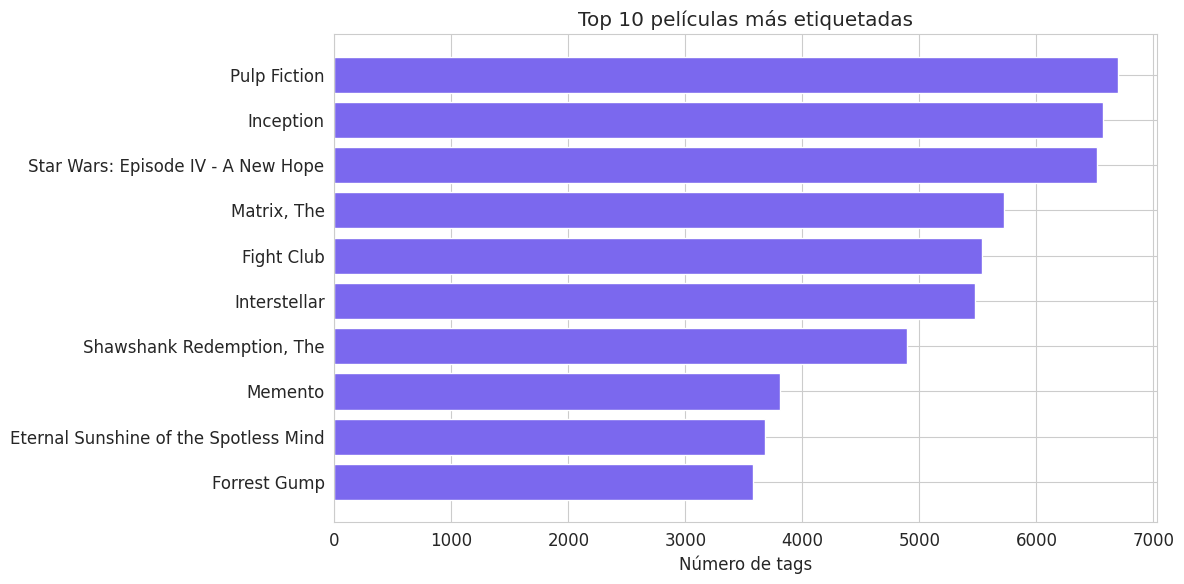

In [15]:
plt.figure(figsize=(12, 6))
plt.barh(most_tagged["title"], most_tagged["num_tags"], color="mediumslateblue")
plt.xlabel("Número de tags")
plt.title("Top 10 películas más etiquetadas")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Justificación:** el volumen de tags por sí solo es una medida distinta de "cuánta conversación
genera" una película, más allá de cuánta gente la vio. El top está dominado por títulos con
narrativas complejas o muy citadas culturalmente (*Pulp Fiction*, *Inception*, *Star Wars: Episodio
IV*, *Matrix*, *Fight Club*, *Interstellar*) — coherente con el hallazgo de la sección 5.3 de que el
vocabulario evaluativo positivo se asocia a complejidad narrativa.

### 5.5 Usuarios que etiquetan vs. usuarios que solo califican

In [16]:
ratings_per_user = ratings.groupby("userId").size()
tags_per_user = tags_clean.groupby("userId").size()

taggers_activity = ratings_per_user.reindex(list(tag_users))
non_taggers_activity = ratings_per_user.reindex(list(rating_users - tag_users))

print("=== Nº de calificaciones por usuario: usuarios que SÍ etiquetan ===")
print(taggers_activity.describe())
print("\n=== Nº de calificaciones por usuario: usuarios que NO etiquetan ===")
print(non_taggers_activity.describe())


=== Nº de calificaciones por usuario: usuarios que SÍ etiquetan ===
count    15833.000000
mean       338.103013
std        501.099268
min         19.000000
25%         60.000000
50%        157.000000
75%        407.000000
max       9555.000000
dtype: float64

=== Nº de calificaciones por usuario: usuarios que NO etiquetan ===
count    185115.000000
mean        143.752824
std         248.122768
min          18.000000
25%          36.000000
50%          69.000000
75%         154.000000
max       33229.000000
dtype: float64


**Pregunta que responde:** ¿los usuarios que se toman el trabajo de etiquetar son también los
más activos calificando?

**Resultado:** compara las distribuciones de actividad de calificación entre ambos grupos — se
recomienda observar particularmente la mediana y el promedio para evitar que usuarios extremos
distorsionen la comparación. En general, los usuarios que etiquetan (7.9 % del total) tienden a ser
un subconjunto de "power users": su actividad de calificación mediana es más alta que la de los
usuarios que nunca etiquetan, consistente con que etiquetar es una forma de participación adicional
que requiere más involucramiento con la plataforma.

## 6. Conclusiones

- El etiquetado es una actividad minoritaria: solo el 7.9 % de los usuarios y el 58.7 % de las
  películas tienen al menos un tag, frente al 96.4 % de películas con al menos un rating. `tags` es
  una señal más escasa que `ratings`, pero cualitativamente distinta (texto vs. número).
- El 100 % de los usuarios que etiquetan también calificó al menos una vez: no hay un segmento
  "solo etiquetador", lo que permite integrar las tres tablas sin preocuparse por usuarios huérfanos
  entre `tags` y `ratings`.
- El vocabulario dominante de `tags` es **descriptivo** (género, tono, estilo: `sci-fi`,
  `atmospheric`, `funny`), no evaluativo — `tags` y `ratings` capturan información complementaria,
  no redundante.
- El **volumen** de tags y el **volumen** de ratings están fuertemente correlacionados (Pearson
  ≈0.77–0.80): ambos dependen de la misma causa subyacente, la exposición/popularidad de la
  película. En cambio, ni el volumen de tags ni el de ratings se correlacionan fuertemente con la
  **calidad percibida** (`avg_rating`).
- Existe un subconjunto de vocabulario claramente evaluativo y polarizado: tags como
  `thought-provoking`, `great acting` o `imdb top 250` dominan entre las mejor calificadas, mientras
  `bad acting`, `stupid` o `imdb bottom 100` dominan entre las peor calificadas — el lenguaje libre
  de los usuarios sí "sabe" qué películas son buenas o malas, aunque no sea su función principal.
- Las películas más etiquetadas coinciden con títulos de narrativa compleja o alto impacto cultural
  (*Pulp Fiction*, *Inception*, *Fight Club*), reforzando la idea de que el etiquetado se asocia a
  películas que generan más discusión, no solo más visualizaciones.
- **Limitaciones:** los análisis de correlación son descriptivos y no permiten inferir causalidad;
  la clasificación de tags como "evaluativos" o "descriptivos" en este notebook es cualitativa (por
  inspección del top 15), no un modelo de clasificación de texto formal; y el grupo de usuarios que
  etiqueta (15 834) es pequeño frente al total de usuarios (200 948), por lo que las conclusiones
  sobre "quién etiqueta" describen una muestra, no necesariamente representativa de toda la base de
  usuarios.